> **AI-generated.** An AI assistant drafted this page, and no maintainer has reviewed it yet. Please report errors on the issue tracker.

# Tutorial 2: Fitting and checking the model

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TARPS-group/prob-pipe/blob/dev/overhaul/docs/tutorials/02_fitting.ipynb)

[Tutorial 1](01_first_analysis.ipynb) built a model of the moose counts and asked what it implies before it sees the data.
This tutorial conditions the model on the counts, checks the sampler and the model, and finds what the model misses.

It continues with three ideas of [how ProbPipe works](../index.md#how-it-works):

1. **One vocabulary of operations:** the posterior is a distribution like the prior, so the operations that applied to the prior apply to it.
2. **Computation from capabilities:** no formula gives this posterior, so `condition_on` selects a sampler, and it reports that its result is approximate.
3. **Lifting:** an ordinary Python function applied to distributions returns the distribution of its output.

In [1]:
# On Google Colab, install ProbPipe and download the data; elsewhere this cell does nothing.
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    import urllib.request

    %pip install --quiet "probpipe-core @ git+https://github.com/TARPS-group/prob-pipe.git@dev/overhaul"
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/TARPS-group/prob-pipe/dev/overhaul/"
        "docs/tutorials/data/moose.csv",
        "data/moose.csv",
    )

In [2]:
import warnings

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from probpipe import (
    Beta,
    LogNormal,
    Poisson,
    condition_on,
    conditional_distribution,
    function,
    mean,
    predictive_check,
    quantile,
    sample,
    workflow_run,
)
from probpipe.diagnostics import add_mcmc_diagnostics

# TensorFlow Probability warns that JAX runs in 32-bit precision, which these models use.
warnings.filterwarnings("ignore", message=r"Explicitly requested dtype float64")

## 1. The model of tutorial 1

This cell repeats tutorial 1's model: the prior of the carrying capacity $K$, the growth rate $r$, and the detection probability $\phi$, and the likelihood of the counts given them.

In [3]:
data = pd.read_csv("data/moose.csv")
years = data["year"].to_numpy()
counts = jnp.asarray(data["count"], dtype=jnp.float32)
YEARS = counts.shape[0]


def trajectory(r: jax.Array, K: jax.Array, n0: float, years: int) -> jax.Array:
    """The population in each of the *years* after the year of *n0*."""

    def step(N: jax.Array, _: None) -> tuple[jax.Array, jax.Array]:
        N_next = N * jnp.exp(r * (1.0 - N / K))
        return N_next, N_next

    _, N = jax.lax.scan(step, jnp.asarray(n0, dtype=jnp.float32), None, length=years)
    return N


prior = (
    LogNormal("K", jnp.log(350.0), 0.4) * LogNormal("r", jnp.log(0.4), 0.4) * Beta("phi", 2.0, 2.0)
).with_label("prior")


def ricker_counts(K: jax.Array, r: jax.Array, phi: jax.Array, n0: float = 50.0) -> Poisson:
    return Poisson("y", phi * trajectory(r, K, n0, YEARS))


likelihood = conditional_distribution(
    ricker_counts, label="counts", given_spec=prior.event_spec.components
)
model = (likelihood * prior).with_label("model")
print("components of the model:", list(model.event_spec.components))

components of the model: ['y', 'K', 'r', 'phi']


## 2. Conditioning on the counts

In tutorial 1, `condition_on` fixed the parameters and returned the distribution of the counts.
Fixing the counts instead returns the distribution of the parameters given the counts, which is the **posterior**.
`check` reports how `condition_on` would compute it:

In [4]:
observed = {"y": counts}
report = condition_on.check(model, observed)
print("route:", report.route)
print("method:", report.method)
print("exact:", report.exact)

route: inference_methods
method: blackjax_nuts
exact: False


No formula gives this posterior.
`condition_on` therefore takes the route `inference_methods`: it multiplies the likelihood by the prior at the counts, by Bayes' rule, and it passes that unnormalized posterior to an inference method.
The method it selects, `blackjax_nuts`, draws from the posterior with the No-U-Turn Sampler (NUTS) of BlackJAX, so the result is approximate.

The call is the same one that tutorial 1 made with parameter values:

In [5]:
with workflow_run(seed=1):
    posterior = condition_on(model, observed)
print("posterior:", posterior)
print("components of the posterior:", list(posterior.event_spec.components))

posterior: model(K, r, phi; y)
components of the posterior: ['K', 'r', 'phi']


The posterior prints as `model(K, r, phi; y)`: it keeps the model's label, its components are the parameters, and `y` after the semicolon is the component that `condition_on` fixed at the counts.

## 3. The posterior is a distribution like the prior

The operations that summarized the prior summarize the posterior.
The table compares the two, with the mean and the 90% interval of each parameter:

In [6]:
levels = jnp.array([0.05, 0.95])
rows = {}
for name in ["K", "r", "phi"]:
    prior_low, prior_high = quantile(prior[name], levels).raw()
    post_low, post_high = quantile(posterior[name], levels).raw()
    rows[name] = {
        "prior mean": float(mean(prior[name])),
        "prior 90% interval": f"({prior_low:.2f}, {prior_high:.2f})",
        "posterior mean": float(mean(posterior[name])),
        "posterior 90% interval": f"({post_low:.2f}, {post_high:.2f})",
    }
pd.DataFrame(rows).T.round(3)

,prior mean,prior 90% interval,posterior mean,posterior 90% interval
K,379.150391,"(181.27, 675.78)",414.584442,"(365.22, 468.66)"
r,0.433315,"(0.21, 0.77)",0.222117,"(0.20, 0.25)"
phi,0.5,"(0.14, 0.86)",0.670988,"(0.58, 0.77)"


The counts narrow every interval: a small population grows at about 0.22 per year, and the survey finds about two thirds of the animals.

`mean` of the whole posterior is a record whose fields name what they hold:

In [7]:
posterior_mean = mean(posterior)
for name, value in posterior_mean.items():
    print(f"{name}:", round(float(value), 3))

mean(K): 414.584
mean(r): 0.222
mean(phi): 0.671


## 4. Draws and exactness

The sampler returns the posterior as 4,000 draws, from four chains of 1,000 draws each, held as an `EmpiricalDistribution`: a distribution on finitely many points, its **atoms**, each with a weight.
Its provenance records how it was computed, and so does the provenance of its mean:

In [8]:
print("type of the posterior:", type(posterior).__name__)
print("number of draws:", posterior.num_atoms)
for name, result in [("posterior", posterior), ("its mean", posterior_mean)]:
    record = result.provenance.metadata
    print(f"{name}: route {record['route']}, exact {record['exact']}")

type of the posterior: EmpiricalDistribution
number of draws: 4000
posterior: route inference_methods, exact False
its mean: route closed_form, exact True


The mean is exact for the 4,000 draws, since `mean` of a distribution on finitely many points is a weighted sum.
The approximation entered one step earlier, when the sampler drew them: exactness belongs to a step, and following the provenance back shows each one.

## 5. Did the sampler work?

The draws describe the posterior only if the chains have mixed.
`add_mcmc_diagnostics` computes the standard checks:

- **R-hat** compares the chains with one another, and a value above 1.01 means they disagree;
- **effective sample size (ESS)** is the number of independent draws the correlated draws are worth, and a few hundred suffice for means and intervals;
- **divergences** are transitions where the sampler failed, and there should be none.

In [9]:
add_mcmc_diagnostics(posterior)
print(posterior.diagnostics.summary_table())
print("divergent transitions:", posterior.diagnostics.mcmc.n_divergences)

Parameter     R-hat     ESS bulk    ESS tail    MCSE mean   
------------------------------------------------------------
K             1.0037    1036.7656   1296.4823   0.9818      
r             1.0041    906.7177    1134.3839   0.0005      
phi           1.0055    829.7070    916.3211    0.0021      

✓  All available diagnostics passed.
divergent transitions: 0


Every R-hat is at most 1.01, every effective sample size is in the hundreds or more, and no transition diverged.
`add_mcmc_diagnostics` recorded these numbers in the posterior's **annotations**, the one part of a ProbPipe object that changes after the object is built.

The annotations also hold the draws as ArviZ data, so ArviZ's plots apply to them.
The pair plot of $K$ and $\phi$ shows that the two trade off: a larger population that the survey finds less often gives the same counts.

posterior correlation of K and phi: -0.87


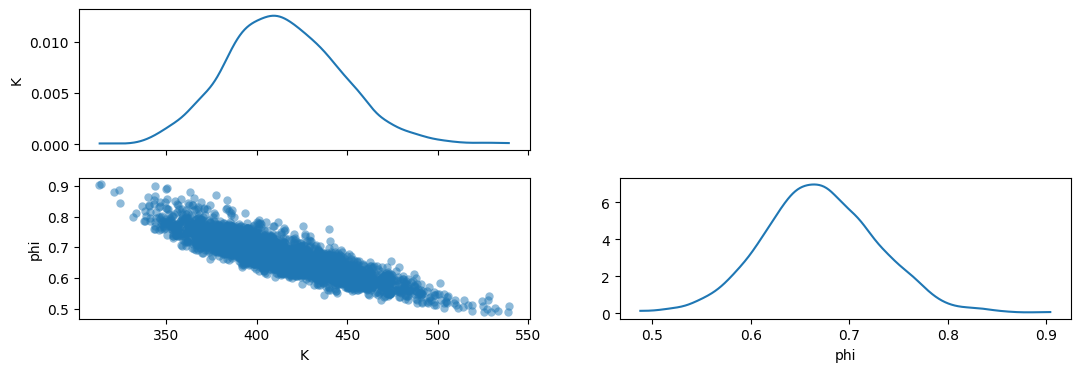

In [10]:
K_draws = np.ravel(posterior.atoms["K"].raw())
phi_draws = np.ravel(posterior.atoms["phi"].raw())
print("posterior correlation of K and phi:", round(float(np.corrcoef(K_draws, phi_draws)[0, 1]), 2))
az.plot_pair(posterior.annotations["arviz"], var_names=["K", "phi"])
plt.show()

The sampler ran four chains of 1,000 draws after 500 warmup steps.
These numbers are settings of the method, which `condition_on.with_options(method_options=...)` changes, as exercise 3 does.

## 6. A function of the parameters

The trade-off suggests a quantity the counts measure better than $K$ or $\phi$ alone: $\phi K$, the count a survey expects when the population is at its carrying capacity.
`@function` makes a Python function into a ProbPipe function.
Applied to distributions, a ProbPipe function returns the distribution of its output, which is called **lifting**.
We apply the same function to the prior and to the posterior:

In [11]:
@function
def capacity_count(K: jax.Array, phi: jax.Array) -> jax.Array:
    return phi * K


with workflow_run(seed=2):
    before = capacity_count(prior["K"], prior["phi"])
    after = capacity_count(posterior["K"], posterior["phi"])
for name, result in [("prior", before), ("posterior", after)]:
    low, high = quantile(result, levels).raw()
    print(f"phi * K under the {name}: mean {float(mean(result)):.0f}, 90% interval ({low:.0f}, {high:.0f})")

phi * K under the prior: mean 189, 90% interval (39, 406)
phi * K under the posterior: mean 276, 90% interval (261, 296)


Under the posterior, the 90% interval of $\phi K$ spans about 13% of its mean, against about 25% for $K$ and 28% for $\phi$: the counts measure the product better than either parameter.
Each evaluation reads $K$ and $\phi$ from the same draw of one distribution, so their trade-off carries through the function.
A lifted function is evaluated at 256 draws by default, and `with_options(n_broadcast_samples=...)` sets the number.

## 7. Predicting new counts

`likelihood * posterior` composes the likelihood with the posterior, as `likelihood * prior` composed the model.
The result is the joint distribution of the parameters and new counts, and its draws of `y` are the counts the fitted model predicts.

fraction of counts inside the 90% predictive band: 0.64


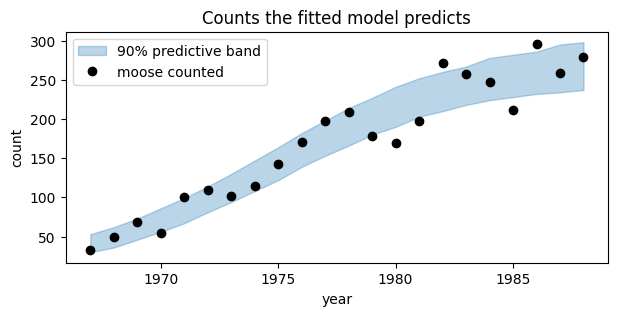

In [12]:
predictions = likelihood * posterior
with workflow_run(seed=3):
    predicted = sample(predictions, sample_shape=(1000,))["y"].raw()
low, high = np.percentile(predicted, [5, 95], axis=0)
inside = np.mean((np.asarray(counts) >= low) & (np.asarray(counts) <= high))
print("fraction of counts inside the 90% predictive band:", round(float(inside), 2))

fig, ax = plt.subplots(figsize=(7, 3))
ax.fill_between(years, low, high, color="tab:blue", alpha=0.3, label="90% predictive band")
ax.plot(years, counts, "o", color="black", label="moose counted")
ax.set(xlabel="year", ylabel="count", title="Counts the fitted model predicts")
ax.legend()
plt.show()

Many counts lie outside the band that should hold 90% of them.
The fitted curve follows the trend, but the counts jump from year to year more than the model allows.

## 8. A predictive check

A posterior predictive check makes this comparison formal.
It computes a statistic of the observed counts and of counts replicated from the fitted model, and its p-value is the fraction of replications whose statistic is at least the observed one.
A p-value near 0 or 1 means the model rarely produces data like the observed.

`predictive_check(likelihood, posterior, statistics, counts)` replicates the counts from `likelihood * posterior`.
We use two statistics: the spread of the year-to-year changes, which measures how much the counts jump, and the largest count.

In [13]:
def change_spread(y: jax.Array) -> jax.Array:
    return jnp.std(jnp.diff(y))


def largest_count(y: jax.Array) -> jax.Array:
    return jnp.max(y)


with workflow_run(seed=4):
    check = predictive_check(likelihood, posterior, [change_spread, largest_count], counts)
for name in ["change_spread", "largest_count"]:
    print(
        f"{name}: observed {float(check[f'{name}/observed_statistic']):.1f},"
        f" p-value {float(check[f'{name}/p_value']):.3f}"
    )

change_spread: observed 31.3, p-value 0.004
largest_count: observed 296.0, p-value 0.114


The model reproduces the largest count, but no replication jumps from year to year as much as the observed counts do.
A population's growth varies from year to year with the weather, food, and predators, and the model has no term for that variation.
[Tutorial 3](03_revising.ipynb) adds one.

## Exercises

Each exercise is followed by a solution, which Colab shows collapsed.

**Exercise 1.** A small population doubles in about $\log(2) / r$ years.
Apply one function that computes the doubling time to the prior and to the posterior, and compare the two 90% intervals.

In [14]:
# @title Solution
@function
def doubling_time(r: jax.Array) -> jax.Array:
    return jnp.log(2.0) / r


with workflow_run(seed=5):
    for name, law in [("prior", prior), ("posterior", posterior)]:
        low, high = quantile(doubling_time(law["r"]), levels).raw()
        print(f"doubling time under the {name}: 90% interval ({low:.1f}, {high:.1f}) years")

doubling time under the prior: 90% interval (0.9, 3.5) years
doubling time under the posterior: 90% interval (2.8, 3.6) years


**Exercise 2.** Write a third statistic, the number of years in which the count fell, and check the model with it.
Does it detect the misfit, as the spread of the changes does?

In [15]:
# @title Solution
def declines(y: jax.Array) -> jax.Array:
    return jnp.sum(jnp.diff(y) < 0).astype(jnp.float32)


with workflow_run(seed=6):
    decline_check = predictive_check(likelihood, posterior, declines, counts)
print("observed number of declines:", float(decline_check["observed_statistic"]))
print("p-value:", round(float(decline_check["p_value"]), 3))
# A p-value near 0.07 is weaker evidence of misfit than the spread of the changes gave.

observed number of declines: 8.0
p-value: 0.066


**Exercise 3.** Fit the model again with two chains of 250 draws each, through `condition_on.with_options(method_options={"num_chains": 2, "num_results": 250})`.
How do the effective sample sizes change?

In [16]:
# @title Solution
with workflow_run(seed=7):
    short = condition_on.with_options(method_options={"num_chains": 2, "num_results": 250})(
        model, observed
    )
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    add_mcmc_diagnostics(short)
messages = [str(caught_warning.message) for caught_warning in caught]
diagnostic_warnings = [message for message in messages if message.startswith(("R-hat", "Low ESS"))]
print("warnings from add_mcmc_diagnostics:", len(diagnostic_warnings))
for message in diagnostic_warnings:
    if message.startswith("R-hat"):
        print("warning:", message)
print("number of draws:", short.num_atoms)
print("smallest bulk ESS with 2 chains of 250:", round(min(short.diagnostics.mcmc.ess_bulk.values())))
print("smallest bulk ESS with 4 chains of 1,000:", round(min(posterior.diagnostics.mcmc.ess_bulk.values())))

warnings from add_mcmc_diagnostics: 8
number of draws: 500
smallest bulk ESS with 2 chains of 250: 101
smallest bulk ESS with 4 chains of 1,000: 830


## Summary

- `condition_on` on the counts returns the posterior, by the same call that fixed parameter values in tutorial 1. No formula gives this posterior, so it applies Bayes' rule and draws from the result with NUTS, and it reports the result as approximate.
- The posterior is a distribution like the prior: `mean`, `quantile`, `sample`, and `*` apply to it, and its draws are an `EmpiricalDistribution`.
- `add_mcmc_diagnostics` checks the sampler, and `predictive_check` checks the model against the data.
- A Python function applied to the posterior returns the distribution of its output, and one function applied to the prior and the posterior shows what the counts taught.
- The model's counts vary less from year to year than the observed counts.

[Tutorial 3](03_revising.ipynb) revises the model and checks the posterior with other algorithms and another modeling language.